In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
signalp_data = pd.read_csv("../../datasets/complete_set_unpartitioned.fasta.csv")
signalp_data.head()

,entry_id,kingdom,sp_type,sequence,annotation
0,Q8TF40,EUKARYA,NO_SP,MAPTLFQKLFSKRTGLGAPGRDARDPDCGFSWPLPEFDPSQIRLIV...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...
1,Q1ENB6,EUKARYA,NO_SP,MDFTSLETTTFEEVVIALGSNVGNRMNNFKEALRLMKDYGISVTRH...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...
2,P36001,EUKARYA,NO_SP,MDDISGRQTLPRINRLLEHVGNPQDSLSILHIAGTNGKETVSKFLT...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...
3,P55317,EUKARYA,NO_SP,MLGTVKMEGHETSDWNSYYADTQEAYSSVPVSNMNSGLGSMNSMNT...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...
4,P35583,EUKARYA,NO_SP,MLGAVKMEGHEPSDWSSYYAEPEGYSSVSNMNAGLGMNGMNTYMSM...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...


## Analysis of all sequences

<Axes: xlabel='kingdom'>

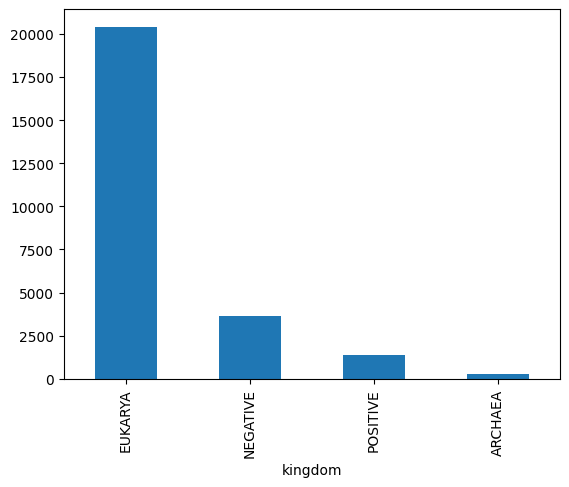

In [4]:
# kingdom distribution
signalp_data["kingdom"].value_counts().plot(kind="bar")

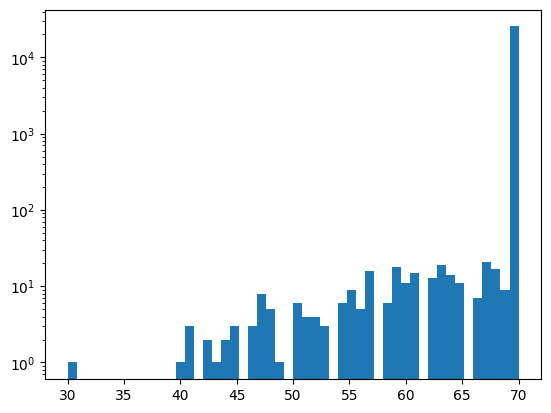

In [5]:
# length distribution
signalp_data["length"] = signalp_data["sequence"].apply(lambda seq: len(seq))
plt.hist(signalp_data["length"], bins=50)
plt.yscale("log")
plt.show()

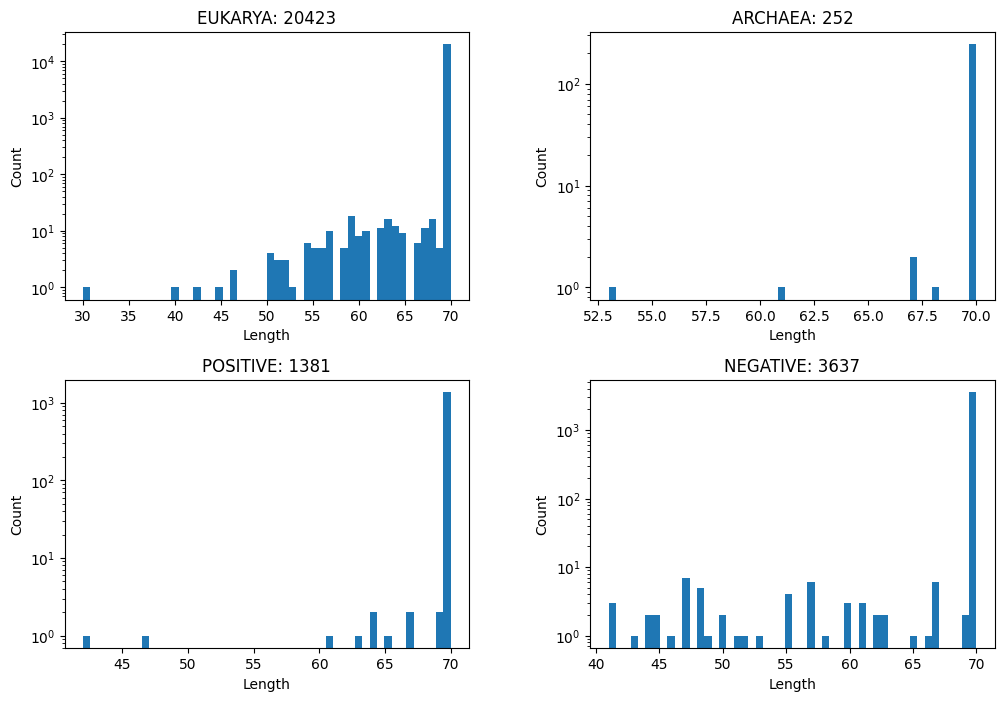

In [34]:
# per kingdom length distribution
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
for kingdom, a in zip(signalp_data["kingdom"].unique(), ax):
    a.hist(signalp_data[signalp_data["kingdom"] == kingdom]["length"], bins=50)
    a.set_yscale("log")
    a.set_title(f"{kingdom}: {len(signalp_data[signalp_data["kingdom"] == kingdom]["length"])}")
    a.set_ylabel("Count")
    a.set_xlabel("Length")

plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

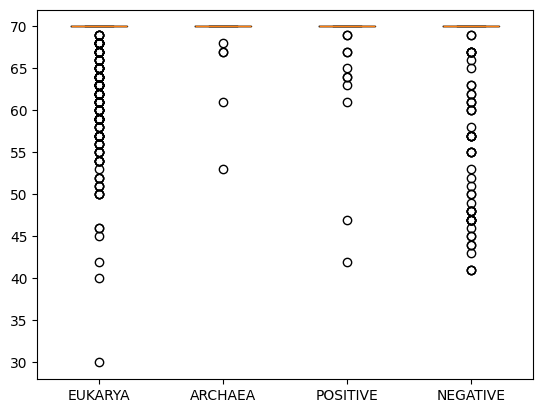

In [ ]:
# per kingdom length distribution as candle and whiskers
data = []
plt.boxplot([signalp_data[signalp_data["kingdom"] == kingdom]["length"] for kingdom in signalp_data["kingdom"].unique()], tick_labels=[kingdom for kingdom in signalp_data["kingdom"].unique()])
plt.show()

In [24]:
# percentage not 70 per kingdom
for kingdom in signalp_data["kingdom"].unique():
    print(f"{kingdom}: Relative: {(len(signalp_data[(signalp_data["kingdom"] == kingdom) & (signalp_data["length"] != 70)]["length"]) / len(signalp_data[signalp_data["kingdom"] == kingdom])) * 100:.2f}%, Total: {len(signalp_data[(signalp_data["kingdom"] == kingdom) & (signalp_data["length"] != 70)]["length"])}")

EUKARYA: Relative: 0.83%, Total: 170
ARCHAEA: Relative: 1.98%, Total: 5
POSITIVE: Relative: 0.80%, Total: 11
NEGATIVE: Relative: 1.59%, Total: 58


## Analysis of Signal Peptide Containing Sequences

In [26]:
print(f"Signal Peptide Percentage: {(len(signalp_data[signalp_data["sp_type"] != "NO_SP"]) / len(signalp_data)) * 100:.2f}%")
for kingdom in signalp_data["kingdom"].unique():
    print(f"Signal Peptide Percentage {kingdom}: {(len(signalp_data[(signalp_data["sp_type"] != "NO_SP") & (signalp_data["kingdom"] == kingdom)]) / len(signalp_data[signalp_data["kingdom"] == kingdom])) * 100:.2f}%")

Signal Peptide Percentage: 25.91%
Signal Peptide Percentage EUKARYA: 13.91%
Signal Peptide Percentage ARCHAEA: 50.79%
Signal Peptide Percentage POSITIVE: 81.32%
Signal Peptide Percentage NEGATIVE: 70.55%


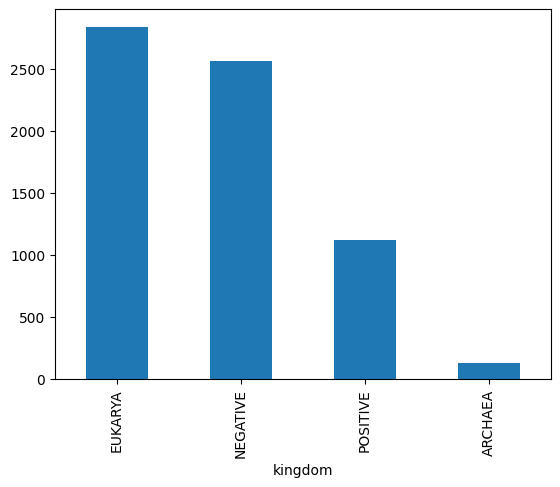

In [ ]:
signalp_data[signalp_data["sp_type"] != "NO_SP"]["kingdom"].value_counts().plot(kind="bar")
plt.show()

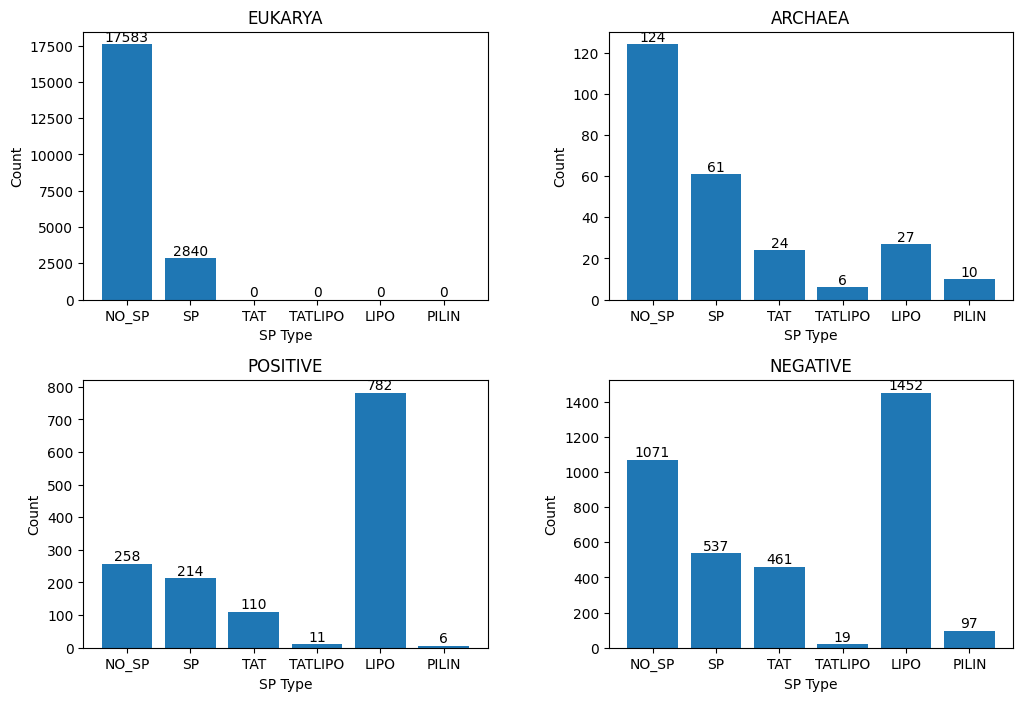

In [43]:
# per kingdom type distribution
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
sp_types = signalp_data["sp_type"].unique()

for kingdom, a in zip(signalp_data["kingdom"].unique(), ax):
    a.set_title(kingdom)
    bars = a.bar(
        sp_types, 
        [len(signalp_data[(signalp_data["kingdom"] == kingdom) & (signalp_data["sp_type"] == sp_type)]) for sp_type in sp_types],
    )
    for bar in bars:
        a.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), bar.get_height(), ha="center", va="bottom")
    a.set_ylabel("Count")
    a.set_xlabel("SP Type")

plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

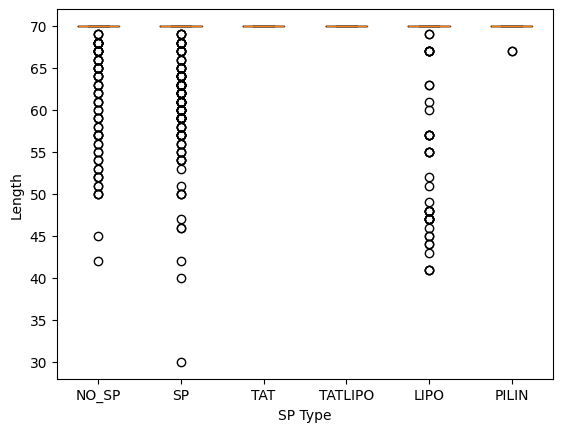

In [41]:
# per type length distribution
plt.boxplot([signalp_data[signalp_data["sp_type"] == sp_type]["length"] for sp_type in sp_types], tick_labels=sp_types)
plt.ylabel("Length")
plt.xlabel("SP Type")
plt.show()

In [ ]:
print(f"Signal Peptide Percentage: {(len(signalp_data[signalp_data["sp_type"] != "NO_SP"]) / len(signalp_data)) * 100:.2f}%")
for kingdom in signalp_data["kingdom"].unique():
    print(f"Signal Peptide Percentage {kingdom}: {(len(signalp_data[(signalp_data["sp_type"] != "NO_SP") & (signalp_data["kingdom"] == kingdom)]) / len(signalp_data[signalp_data["kingdom"] == kingdom])) * 100:.2f}%")

In [ ]:
# TODO: per kingdom per type length distribution